In [9]:
import pandas as pd 
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [6]:
# Reading CSV file
df = pd.read_csv("netflix_titles.csv")
print(df[['release_year', 'rating', 'duration']].head())

   release_year rating   duration
0          2020  PG-13     90 min
1          2021  TV-MA  2 Seasons
2          2021  TV-MA   1 Season
3          2021  TV-MA   1 Season
4          2021  TV-MA  2 Seasons


In [7]:
if df['rating'].dtype == 'object':
    le = LabelEncoder()
    df['rating'] = le.fit_transform(df['rating'].astype(str))

def extract_duration(duration):
    if pd.isna(duration):
        return 0
    if 'Season' in duration:
        return int(duration.split()[0]) * 60  #1 season = 60 minutes
    else:
        return int(duration.split()[0])

df['duration'] = df['duration'].apply(extract_duration)

# Columns to scale
cols_to_scale = ['release_year', 'rating', 'duration']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[cols_to_scale])

print(df_scaled[:5])


[[ 0.65993048 -1.53739993 -0.19931352]
 [ 0.77332444  0.50028112  0.32229055]
 [ 0.77332444  0.50028112 -0.7209176 ]
 [ 0.77332444  0.50028112 -0.7209176 ]
 [ 0.77332444  0.50028112  0.32229055]]


In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters=kmeans.fit_predict(df_scaled)
df_scaled_clusters = df.copy()
df_scaled_clusters['cluster']=clusters

In [14]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

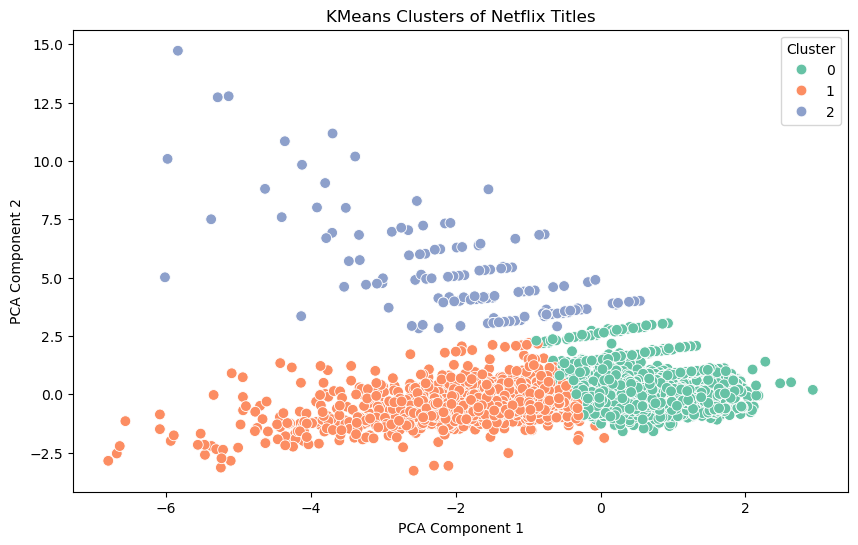

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=clusters, palette='Set2', s=60)
plt.title("KMeans Clusters of Netflix Titles")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.show()